# (IIP314W) Optimización Aplicada a Negocios
## Ayudantía 6: Método Simplex

---

**Profesor:** Ing. Rodrigo Trigo Vilches  
**Ayudante:** Lic. Vicente Ramírez Almonacid  
**Fecha:** 15 de Abril, 2026  
**Universidad del Desarrollo**

---

## 1. ¿Qué es el Método Simplex?

El **Método Simplex** (Dantzig, 1947) es el algoritmo clásico para resolver problemas de **Programación Lineal (PL)**. Dado un problema de la forma:

$$\max \quad z = c^\top x \qquad \text{s.a.} \quad Ax \leq b, \quad x \geq 0$$

### Fundamento Geométrico

La región factible de un PL es un **poliedro convexo**. Como la función objetivo es lineal, su máximo (o mínimo) siempre se alcanza en uno de los **vértices** (puntos extremos) del poliedro.

> El Simplex recorre de forma eficiente los vértices del poliedro, mejorando el valor de $z$ en cada paso, hasta alcanzar el óptimo.

### Forma Estándar y Bases

Para aplicar el algoritmo se introduce la **forma estándar**: se agregan variables de holgura $s_i \geq 0$ para convertir cada desigualdad en igualdad.

$$ Ax \leq b \quad \xrightarrow{\text{holguras}} \quad [A \mid I]\begin{bmatrix}x \\ s\end{bmatrix} = b $$

Cada vértice del poliedro corresponde a una **Solución Básica Factible (SBF)**: exactamente $m$ variables son positivas (**variables básicas**, forman la base $B$) y el resto vale cero (**variables no básicas**).

### Reglas del Algoritmo

| Paso | Criterio | Descripción |
|:---:|:---|:---|
| 1 | **Optimalidad** | Si todos los costos reducidos son $\geq 0$, la SBF actual es óptima. |
| 2 | **Variable que entra** | La variable no básica con el costo reducido más negativo (regla de Dantzig). |
| 3 | **Variable que sale** | Cociente mínimo: $\min\{ b_i / a_{ik} \mid a_{ik} > 0 \}$ — garantiza factibilidad. |
| 4 | **Pivoteo** | Operación de Gauss-Jordan sobre la columna de entrada para actualizar el tableau. |

### Dos Implementaciones

| | Simplex Tableau | Simplex Matricial |
|:---|:---|:---|
| **Operación central** | Pivoteo fila a fila (Gauss-Jordan) | Cálculo de $B^{-1}$ en cada iteración |
| **Ventaja** | Visual e intuitivo | Sistemático y generalizable |
| **Uso típico** | Resolver a mano, aprendizaje | Implementación computacional, análisis de sensibilidad |

---

## 2. Ejercicio: Simplex Tableau

### Contexto

Una empresa de calzado deportivo fabrica dos modelos de zapatillas: **Runner** ($x_1$) y **Trail** ($x_2$). La empresa desea determinar cuántos pares de cada modelo producir por día para **maximizar su utilidad neta**.

| Recurso | Runner ($x_1$) | Trail ($x_2$) | Disponible |
|:---|:---:|:---:|:---:|
| Cuero reforzado (kg) | $1$ | $0$ | $4$ kg |
| Suela especial (unid.) | $0$ | $2$ | $12$ unid. |
| Horas de costura | $3$ | $2$ | $18$ hrs |
| **Utilidad (\$/par)** | **\$3** | **\$5** | — |

### Formulación

$$\max \quad z = 3x_1 + 5x_2$$

$$\text{s.a.} \quad \begin{cases} x_1 \leq 4 \\ 2x_2 \leq 12 \\ 3x_1 + 2x_2 \leq 18 \\ x_1, x_2 \geq 0 \end{cases}$$

### Forma Estándar

Introducimos **variables de holgura** $x_3, x_4, x_5 \geq 0$:

$$\max \quad z = 3x_1 + 5x_2$$

$$\text{s.a.} \quad \begin{cases} x_1 + x_3 = 4 \\ 2x_2 + x_4 = 12 \\ 3x_1 + 2x_2 + x_5 = 18 \\ x_1, x_2, x_3, x_4, x_5 \geq 0 \end{cases}$$

**Base inicial:** $\{x_3, x_4, x_5\}$ — corresponde al vértice $(0,0)$, con $x_3=4,\; x_4=12,\; x_5=18$ y $z=0$.

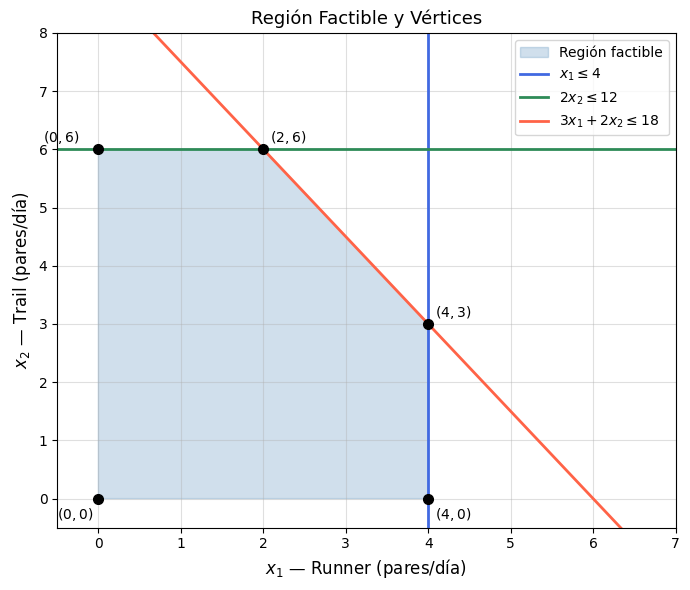

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

x1 = np.linspace(0, 7, 500)

# Fronteras de las restricciones
x2_r3 = (18 - 3 * x1) / 2

# Vértices de la región factible
vertices = np.array([[0, 0], [4, 0], [4, 3], [2, 6], [0, 6]])

fig, ax = plt.subplots(figsize=(7, 6))

# Región factible
poly = Polygon(vertices, alpha=0.25, color='steelblue', label='Región factible')
ax.add_patch(poly)

# Restricciones
ax.axvline(x=4, color='royalblue', linewidth=2, label='$x_1 \\leq 4$')
ax.axhline(y=6, color='seagreen', linewidth=2, label='$2x_2 \\leq 12$')
ax.plot(x1, x2_r3, color='tomato', linewidth=2, label='$3x_1 + 2x_2 \\leq 18$')

# Vértices
labels = ['$(0,0)$', '$(4,0)$', '$(4,3)$', '$(2,6)$', '$(0,6)$']
offsets = [(-30,-15), (5,-15), (5,5), (5,5), (-40,5)]
for v, lbl, off in zip(vertices, labels, offsets):
    ax.plot(v[0], v[1], 'ko', markersize=7, zorder=4)
    ax.annotate(lbl, v, textcoords='offset points', xytext=off, fontsize=10)

ax.set_xlim(-0.5, 7)
ax.set_ylim(-0.5, 8)
ax.set_xlabel('$x_1$ — Runner (pares/día)', fontsize=12)
ax.set_ylabel('$x_2$ — Trail (pares/día)', fontsize=12)
ax.set_title('Región Factible y Vértices', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Resolución por Tableau

Construya el tableau inicial y aplique el algoritmo Simplex hasta alcanzar la solución óptima.

**Tableau Inicial (Iteración 0)**

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | | | | | | |
| $x_3$ | | | | | | |
| $x_4$ | | | | | | |
| $x_5$ | | | | | | |

---

**Iteración 1**

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |

---

**Iteración 2**

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | | | | | | |
| | | | | | | |
| | | | | | | |
| | | | | | | |

In [ ]:
from scipy.optimize import linprog

# Verificar el resultado con scipy
# (linprog minimiza → negar la función objetivo)

#### CÓDIGO AQUÍ ####

#####################

---

## 3. Mismo Ejercicio: Simplex Matricial

El **Simplex Matricial** resuelve el mismo problema usando operaciones matriciales en lugar de pivoteo fila a fila. En cada iteración se actualiza la **base** $B$ (matriz cuyas columnas corresponden a las variables básicas del sistema $[A \mid I]$) y se calculan:

| Fórmula | Descripción |
|:---|:---|
| $c_B B^{-1} A_{NB} - c_{NB}$ | Costos reducidos de las variables no básicas |
| $B^{-1} a_k$ | Columna actualizada de la variable $k$ que entra |
| $B^{-1} b$ | Valores actuales de las variables básicas (RHS) |
| $c_B B^{-1} b$ | Valor actual de la función objetivo |

Donde:
- $B$: matriz de columnas básicas (del sistema $[A \mid I]$)
- $c_B$: coeficientes de la función objetivo para las variables básicas
- $A_{NB}$: columnas de las variables **no** básicas
- $b = [4, 12, 18]^\top$

### Sistema $[A \mid I]$

$$[A \mid I] = \begin{bmatrix} 1 & 0 & 1 & 0 & 0 \\ 0 & 2 & 0 & 1 & 0 \\ 3 & 2 & 0 & 0 & 1 \end{bmatrix}$$

donde las columnas corresponden a $x_1, x_2, x_3, x_4, x_5$ respectivamente.

In [ ]:
import numpy as np
from numpy.linalg import inv

# RHS del sistema
b = np.array([4, 12, 18], dtype=float)

# Columnas del sistema [A | I] para cada variable
cols = {
    'x1': np.array([1, 0, 3], dtype=float),
    'x2': np.array([0, 2, 2], dtype=float),
    'x3': np.array([1, 0, 0], dtype=float),
    'x4': np.array([0, 1, 0], dtype=float),
    'x5': np.array([0, 0, 1], dtype=float),
}

# Coeficientes en la función objetivo
c_obj = {'x1': 3, 'x2': 5, 'x3': 0, 'x4': 0, 'x5': 0}

### Iteración 0

**Base inicial:** $\{x_3, x_4, x_5\}$ → $B = I_3$, $c_B = [0,\; 0,\; 0]$.

Siga los pasos a continuación para completar la iteración:

**Paso 1 — Construir $B$ y $B^{-1}$**

| Variable | Columna en $[A \mid I]$ |
|:---:|:---:|
| $x_3$ | $[\;,\;,\;]^\top$ |
| $x_4$ | $[\;,\;,\;]^\top$ |
| $x_5$ | $[\;,\;,\;]^\top$ |

$$B = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix} \qquad B^{-1} = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix}$$

**Paso 2 — Costos reducidos** (variables no básicas: $x_1, x_2$)

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [\quad,\quad]$$

Variable que entra: __________ (costo reducido más negativo: ______)

**Paso 3 — Prueba del cociente**

Columna de la variable que entra: $B^{-1} a_k = [\quad,\quad,\quad]^\top$

| Base | $B^{-1}b$ | $B^{-1}a_k$ | Cociente |
|:---:|:---:|:---:|:---:|
| $x_3$ | | | |
| $x_4$ | | | |
| $x_5$ | | | |

Variable que sale: __________  $\Rightarrow$  Nueva base: $\{\quad,\quad,\quad\}$

In [ ]:
# --- Iteración 0 ---
base    = ['x3', 'x4', 'x5']
nonbase = ['x1', 'x2']

#### CÓDIGO AQUÍ ####

#####################

### Iteración 1

Actualice la base según el resultado de la iteración anterior y repita el proceso.

**Paso 1 — Construir $B$ y $B^{-1}$**

| Variable | Columna en $[A \mid I]$ |
|:---:|:---:|
| $\_\_$ | $[\;,\;,\;]^\top$ |
| $\_\_$ | $[\;,\;,\;]^\top$ |
| $\_\_$ | $[\;,\;,\;]^\top$ |

$$B = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix} \qquad B^{-1} = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix}$$

**Paso 2 — Costos reducidos** (variables no básicas: $\_\_, \_\_$)

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [\quad,\quad]$$

Variable que entra: __________ (costo reducido más negativo: ______)

**Paso 3 — Prueba del cociente**

Columna de la variable que entra: $B^{-1} a_k = [\quad,\quad,\quad]^\top$

| Base | $B^{-1}b$ | $B^{-1}a_k$ | Cociente |
|:---:|:---:|:---:|:---:|
| | | | |
| | | | |
| | | | |

Variable que sale: __________  $\Rightarrow$  Nueva base: $\{\quad,\quad,\quad\}$

In [ ]:
# --- Iteración 1 ---
# base    = [...]
# nonbase = [...]

#### CÓDIGO AQUÍ ####

#####################

### Iteración 2

Actualice la base según el resultado de la iteración anterior. Verifique la condición de optimalidad.

**Paso 1 — Construir $B$ y $B^{-1}$**

| Variable | Columna en $[A \mid I]$ |
|:---:|:---:|
| $\_\_$ | $[\;,\;,\;]^\top$ |
| $\_\_$ | $[\;,\;,\;]^\top$ |
| $\_\_$ | $[\;,\;,\;]^\top$ |

$$B = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix} \qquad B^{-1} = \begin{bmatrix} & & \\ & & \\ & & \end{bmatrix}$$

**Paso 2 — Costos reducidos** (variables no básicas: $\_\_, \_\_$)

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [\quad,\quad]$$

¿Se cumple la condición de optimalidad? _____ ¿Por qué? ______________________________

**Paso 3 — Solución óptima**

$$B^{-1}b = \begin{bmatrix} \\ \\ \end{bmatrix} \;\Rightarrow\; \_\_=\_\_,\quad \_\_=\_\_,\quad \_\_=\_\_$$

$$z^* = c_B \cdot B^{-1}b = \_\_\_\_$$

In [ ]:
# --- Iteración 2 ---
# base    = [...]
# nonbase = [...]

#### CÓDIGO AQUÍ ####

#####################